# Module 0 — Data Understanding & Preparation
**Course:** Data Mining 2 | **Dataset:** Child Mind Institute – Problematic Internet Use
**Goal:** Load raw data, explore structure and missingness, perform stratified train/test split, build preprocessing pipeline, and save processed datasets for downstream modules.


## 0.1 — Setup: Imports and Configuration

In [1]:
# ── Standard library ───────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Core data / plotting ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn preprocessing ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# ── Global settings ─────────────────────────────────────────────────────────
RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', 50)

# ── Paths ────────────────────────────────────────────────────────────────────
# Put the raw CSV files in the same folder as this notebook,
# or adjust the path below.
DATA_PATH = '../data/cmi_internet.csv'   # tabular data
OUT_DIR   = '../outputs/'                # processed CSVs + figures

import os
os.makedirs(OUT_DIR, exist_ok=True)

print("Setup complete.")

Setup complete.


## 0.2 — Load Raw Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df.shape}  (rows × columns)")
df.head(3)

Raw shape: (8460, 82)  (rows × columns)


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,...,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,26.0,NaN,NaN,114.0,Spring,5.0,7.0,28.0,Fall,0.0,0.0,NaN,NaN,NaN,NaN,...,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,22.0,75.0,70.0,122.0,NaN,NaN,NaN,28.0,Fall,3.0,0.0,NaN,2.0,NaN,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,NaN,65.0,94.0,117.0,Fall,5.0,7.0,33.0,Fall,20.0,1.0,10.2,1.0,14.7,2.0,...,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0


In [3]:
# Column overview
print("Column names:")
print(df.columns.tolist())

Column names:
['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP', 'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec', 'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU', 'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'PAQ_A-Season', 'PAQ_A-PAQ_A_Total', 'PAQ_C-Season'

In [4]:
# Data types
print(df.dtypes.value_counts())
print("\nSample dtypes:")
print(df.dtypes.head(20))

float64    68
object     11
int64       3
Name: count, dtype: int64

Sample dtypes:
id                                int64
Basic_Demos-Enroll_Season        object
Basic_Demos-Age                   int64
Basic_Demos-Sex                   int64
CGAS-Season                      object
CGAS-CGAS_Score                 float64
Physical-Season                  object
Physical-BMI                    float64
Physical-Height                 float64
Physical-Weight                 float64
Physical-Waist_Circumference    float64
Physical-Diastolic_BP           float64
Physical-HeartRate              float64
Physical-Systolic_BP            float64
Fitness_Endurance-Season         object
Fitness_Endurance-Max_Stage     float64
Fitness_Endurance-Time_Mins     float64
Fitness_Endurance-Time_Sec      float64
FGC-Season                       object
FGC-FGC_CU                      float64
dtype: object


## 0.3 — Target Variable: `sii`

`sii` = Severity Impairment Index (ordinal: 0=None, 1=Mild, 2=Moderate, 3=Severe)  
Derived from PCIAT_Total scores via binning — **PCIAT columns are leakage and will be dropped**.

     Count  Pct (%)
sii                
0.0   5833     68.9
1.0   1587     18.8
2.0    952     11.3
3.0     88      1.0

Missing values in target: 0


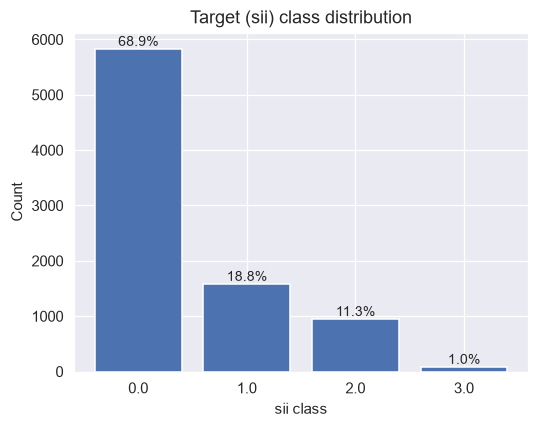

In [5]:
TARGET = 'sii'

# Class distribution
counts = df[TARGET].value_counts().sort_index()
pcts   = df[TARGET].value_counts(normalize=True).sort_index() * 100
dist   = pd.DataFrame({'Count': counts, 'Pct (%)': pcts.round(1)})
dist.index.name = 'sii'
print(dist)
print(f"\nMissing values in target: {df[TARGET].isna().sum()}")

# ── Figure 1: target distribution ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.index.astype(str), counts.values, color='#4C72B0')
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{pct:.1f}%", ha='center', fontsize=9)
ax.set_xlabel('sii class'); ax.set_ylabel('Count')
ax.set_title('Target (sii) class distribution')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig1_target_distribution.png', dpi=110)
plt.show()

## 0.4 — Feature Leakage: Drop PCIAT Columns and `id`

`sii` is computed directly from `PCIAT_Total` → keeping PCIAT columns = perfect leakage.

In [6]:
pciat_cols = [c for c in df.columns if c.startswith('PCIAT')]
print(f"PCIAT columns to drop ({len(pciat_cols)}): {pciat_cols}")

df_clean = df.drop(columns=pciat_cols + ['id'])
print(f"\nShape after leakage removal: {df_clean.shape}")

PCIAT columns to drop (22): ['PCIAT-Season', 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02', 'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_06', 'PCIAT-PCIAT_07', 'PCIAT-PCIAT_08', 'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10', 'PCIAT-PCIAT_11', 'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14', 'PCIAT-PCIAT_15', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_18', 'PCIAT-PCIAT_19', 'PCIAT-PCIAT_20', 'PCIAT-PCIAT_Total']

Shape after leakage removal: (8460, 59)


## 0.5 — Missingness Analysis

In [7]:
# ── Instrument block mapping ────────────────────────────────────────────────
INSTRUMENT_BLOCKS = {
    'Basic_Demos':    'Demographics',
    'CGAS':           'Children Global Assessment Scale',
    'Physical':       'Physical Measures',
    'Fitness_Endurance': 'FitnessGram Vitals/Treadmill',
    'FGC':            'FitnessGram Child',
    'BIA':            'Bio-electric Impedance Analysis',
    'PAQ_A':          'Physical Activity Questionnaire (Adolescent)',
    'PAQ_C':          'Physical Activity Questionnaire (Child)',
    'SDS':            'Sleep Disturbance Scale',
    'PreInt_EduHx':   'Pre-Intake Education History',
}

def get_block(col):
    for prefix, label in INSTRUMENT_BLOCKS.items():
        if col.startswith(prefix):
            return label
    return 'Other'

features = df_clean.drop(columns=[TARGET])
season_cols  = [c for c in features.columns if 'Season' in c]
numeric_cols = [c for c in features.columns if c not in season_cols]
print(f"Total features: {features.shape[1]}  |  numeric: {len(numeric_cols)}  |  season: {len(season_cols)}")

Total features: 58  |  numeric: 48  |  season: 10


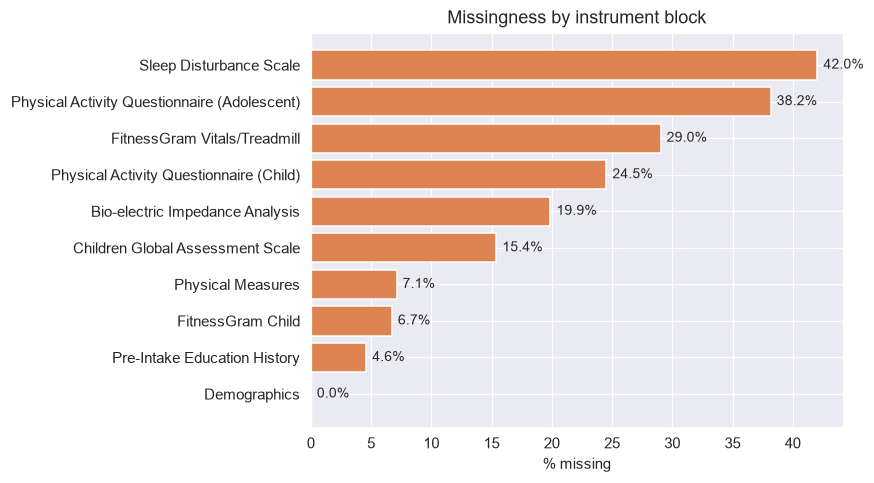

In [8]:
# ── Figure 2: missingness per instrument block ──────────────────────────────
block_missing = {}
for c in season_cols:
    block_missing[get_block(c)] = df_clean[c].isna().mean() * 100

block_missing = dict(sorted(block_missing.items(), key=lambda x: -x[1]))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(list(block_missing.keys()), list(block_missing.values()), color='#DD8452')
ax.set_xlabel('% missing'); ax.set_title('Missingness by instrument block')
for i, v in enumerate(block_missing.values()):
    ax.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig2_missingness_by_block.png', dpi=110)
plt.show()

Rows with 0 missing:        35
Rows with >50% missing:     226


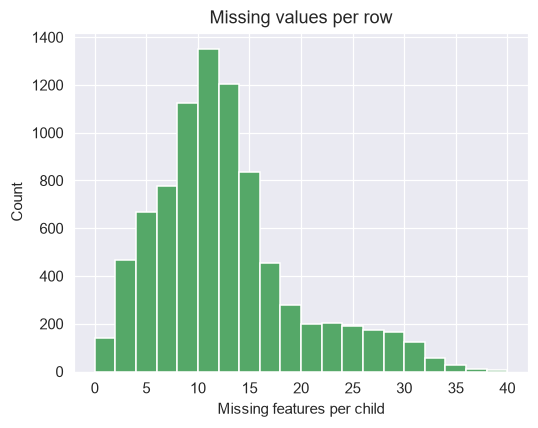

In [9]:
# ── Figure 3: missing values per row ───────────────────────────────────────
miss_per_row = features.isna().sum(axis=1)
print(f"Rows with 0 missing:        {(miss_per_row == 0).sum()}")
print(f"Rows with >50% missing:     {(miss_per_row > features.shape[1]/2).sum()}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(miss_per_row, bins=20, color='#55A868', edgecolor='white')
ax.set_xlabel('Missing features per child'); ax.set_ylabel('Count')
ax.set_title('Missing values per row')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig3_missing_per_row.png', dpi=110)
plt.show()

## 0.6 — Train / Test Split

**Stratified 75/25 split on `sii`, performed BEFORE any cleaning.**  
This ensures no test-set information leaks into the preprocessing pipeline.

In [10]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print(f"Train:  {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")
print("\nClass distribution (train):")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(1))
print("\nClass distribution (test):")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(1))

Train:  6345 rows  |  Test: 2115 rows

Class distribution (train):
sii
0.0    69.0
1.0    18.8
2.0    11.3
3.0     1.0
Name: proportion, dtype: float64

Class distribution (test):
sii
0.0    68.9
1.0    18.8
2.0    11.3
3.0     1.0
Name: proportion, dtype: float64


## 0.7 — Preprocessing Pipeline

Steps:
1. **Missingness flags** — one binary flag per instrument block (1 = block entirely missing for this child)
2. **Season columns** — fill NaN with `'Missing'` category, then one-hot encode
3. **Numeric imputation** — median imputation, fitted on training set only

In [11]:
def add_missing_flags(X_part, ref_cols, block_fn):
    """Add one binary flag per instrument block = 1 if any column missing."""
    X_part = X_part.copy()
    blocks = {}
    for c in ref_cols:
        b = block_fn(c)
        blocks.setdefault(b, []).append(c)
    for b, cols in blocks.items():
        flag_name = f"flag_missing_{b.replace(' ', '_')}"
        X_part[flag_name] = X_part[cols].isna().any(axis=1).astype(int)
    return X_part

# Step 1: add missingness flags
X_train_p = add_missing_flags(X_train, numeric_cols, get_block)
X_test_p  = add_missing_flags(X_test,  numeric_cols, get_block)
print(f"Features after adding flags: {X_train_p.shape[1]}")

Features after adding flags: 68


In [12]:
# Step 2: Season columns — fill NaN -> 'Missing', then one-hot encode
for c in season_cols:
    X_train_p[c] = X_train_p[c].fillna('Missing')
    X_test_p[c]  = X_test_p[c].fillna('Missing')

X_train_enc = pd.get_dummies(X_train_p, columns=season_cols, prefix=season_cols)
X_test_enc  = pd.get_dummies(X_test_p,  columns=season_cols, prefix=season_cols)
# Align columns (test may be missing some dummy categories)
X_test_enc  = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
print(f"Features after one-hot encoding: {X_train_enc.shape[1]}")

Features after one-hot encoding: 107


In [13]:
# Step 3: Numeric imputation — median, fit on TRAIN only
imputer = SimpleImputer(strategy='median')
X_train_enc[numeric_cols] = imputer.fit_transform(X_train_enc[numeric_cols])
X_test_enc[numeric_cols]  = imputer.transform(X_test_enc[numeric_cols])

print(f"Missing values remaining (train): {X_train_enc.isna().sum().sum()}")
print(f"Missing values remaining (test):  {X_test_enc.isna().sum().sum()}")
print(f"\nFinal feature count: {X_train_enc.shape[1]}")

Missing values remaining (train): 0
Missing values remaining (test):  0

Final feature count: 107


## 0.8 — Correlation Analysis

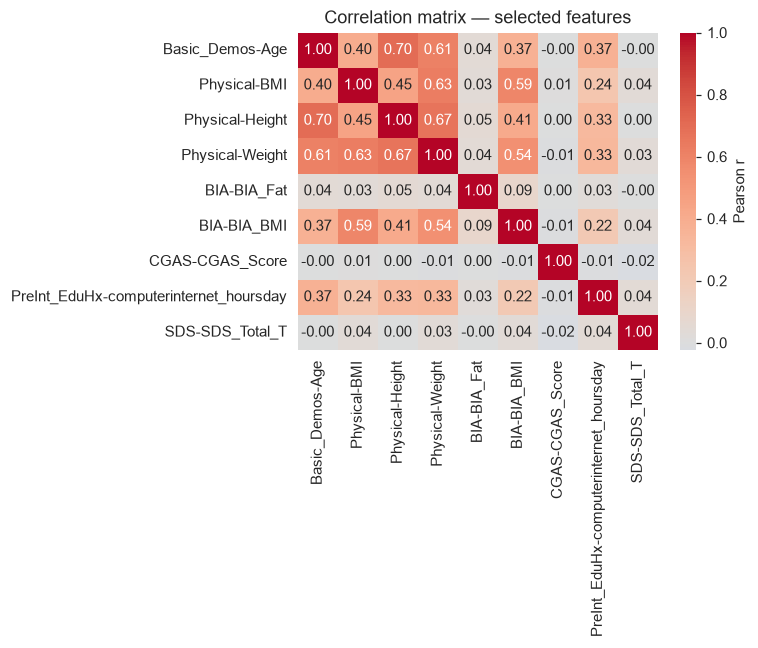

In [14]:
# Inspect correlation between key features
key_features = [
    'Basic_Demos-Age', 'Physical-BMI', 'Physical-Height', 'Physical-Weight',
    'BIA-BIA_Fat', 'BIA-BIA_BMI', 'CGAS-CGAS_Score',
    'PreInt_EduHx-computerinternet_hoursday', 'SDS-SDS_Total_T'
]
key_features = [f for f in key_features if f in X_train_enc.columns]
corr = X_train_enc[key_features].corr()

# ── Figure 4: correlation heatmap ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation matrix — selected features')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig4_correlation_matrix.png', dpi=110)
plt.show()

## 0.9 — Save Processed Datasets

In [15]:
X_train_enc.to_csv(OUT_DIR + 'X_train_processed.csv', index=False)
X_test_enc.to_csv( OUT_DIR + 'X_test_processed.csv',  index=False)
y_train.to_csv(    OUT_DIR + 'y_train.csv',            index=False)
y_test.to_csv(     OUT_DIR + 'y_test.csv',             index=False)

summary = pd.DataFrame({
    'Stage': ['Raw dataset', 'After dropping PCIAT + id', 'After encoding + flags + imputation'],
    'Rows':    [df.shape[0],  X.shape[0],  X_train_enc.shape[0]],
    'Columns': [df.shape[1],  X.shape[1],  X_train_enc.shape[1]],
})
print(summary.to_string(index=False))
print("\n✅ Module 0 complete. Outputs saved to:", OUT_DIR)

                              Stage  Rows  Columns
                        Raw dataset  8460       82
          After dropping PCIAT + id  8460       58
After encoding + flags + imputation  6345      107

✅ Module 0 complete. Outputs saved to: ../outputs/
